<a href="https://colab.research.google.com/github/NickLarsonUVA/DS3001-programming/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
*  The basic idea is that we want to stop the model from memorizing the training data. If we just look at standard mean squared error, a model might create wildly huge coefficients just to perfectly hit every single data point. By adding a penalty for large parameters, we are basically telling the model, "Try to fit the data, but keep your math simple." It forces the model to only use large weights if they really help improve the predictions, which prevents overfitting.
2. How does regularization provide a way of exploring the bias-variance trade-off?
*   Regularization gives us a dial we can turn to balance the two. When we crank up the penalty, we force the model to be simpler. This increases bias (it might miss out on some complex patterns) but drops the variance (it won't wildly overreact to new, unseen data). If we turn the penalty down, the model becomes more complex, which lowers the bias but increases the risk of high variance (overfitting). Tuning that penalty lets us slide along the scale to find the sweet spot.
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
*  The main difference is how they calculate the penalty. Ridge looks at the squared value of the parameters. It shrinks all the coefficients down toward zero, but it rarely ever makes them exactly zero. It's great when you want to keep all your variables but just weaken their impact. LASSO looks at the absolute value of the parameters. Because of how the math works out, LASSO will actually force some of the coefficients to become exactly zero. This makes LASSO really useful for feature selection because it essentially throws out the variables that don't matter.
4. How do we typically scale variables for use in regularized regression? Why?
*  We typically "z-score normalize" our numeric variables (though we leave dummy/one-hot encoded variables alone). We have to do this because the penalty makes the model compare the variables based on their coefficients. If the variables are on completely different scales, it can artificially boost some variables over others and make the math unstable. Normalizing them makes it a fair comparison.
5. How is the penalty $\alpha$ typically selected?
*  We pick $\alpha$ using k-fold cross-validation. Basically, you set up a "grid" of different $\alpha$ values to test out. For each $\alpha$ in the grid, you run cross-validation to see what its Mean Squared Error (MSE) is. Then, you just pick the $\alpha$ that gives you the lowest average (or median) MSE across your tests.
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
*  No, you don't include the penalty term when evaluating the test folds. During cross-validation, you only use the penalty on the training folds to help the model pick the best coefficients. But when it comes time to evaluate the model on the test folds, you drop the penalty and just use the regular MSE. You do this because you only want to measure the actual prediction error of the model, not the artificial cost of the penalty.

In [1]:
! git clone https://github.com/NickLarsonUVA/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 51 (delta 13), reused 6 (delta 6), pack-reused 32 (from 1)
Receiving objects: 100% (51/51), 132.11 KiB | 614.00 KiB/s, done.
Resolving deltas: 100% (22/22), done.
Download complete
Extracting data files...
Data extracted


**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [2]:
#Q2 - 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

# dataset
df = pd.read_csv('/content/data/cars_hw.csv')

# Create the Age variable (Assuming current year is 2024)
df['Age'] = 2024 - df['Make_Year']

# Define our features (X) and target (y)
features = ['Mileage_Run', 'Age']
X = df[features]
y = df['Price']

# (a) Use PolynomialFeatures to create a third degree expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(features)

# (b) Use StandardScaler to z-score normalize them
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [3]:
#Q2 - 2
# Run standard Linear Regression
lr = LinearRegression()
lr.fit(X_scaled, y)

# Find the sign for the interaction between Mileage_Run and Age
# The interaction term name is usually 'Mileage_Run Age'
interaction_idx = list(feature_names).index('Mileage_Run Age')
interaction_coef = lr.coef_[interaction_idx]

print(f"The sign for the interaction is: {'Positive' if interaction_coef > 0 else 'Negative'}")

The sign for the interaction is: Negative


The negative sign shows that Age and Mileage compound each other's effects. As a car gets older, the penalty for having high mileage gets stronger.

In [4]:
#Q2 - 3
# Create the grid of alpha values based on the hint
alphas = np.logspace(1, 3, 20)

# Run LassoCV with 20-fold cross validation
# added max_iter=50000 to prevent the ConvergenceWarnings
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=50000, random_state=100)
lasso_cv.fit(X_scaled, y)

# Print the optimal cost parameter selected
print(f"optimal alpha: {lasso_cv.alpha_}")

optimal alpha: 483.2930238571752


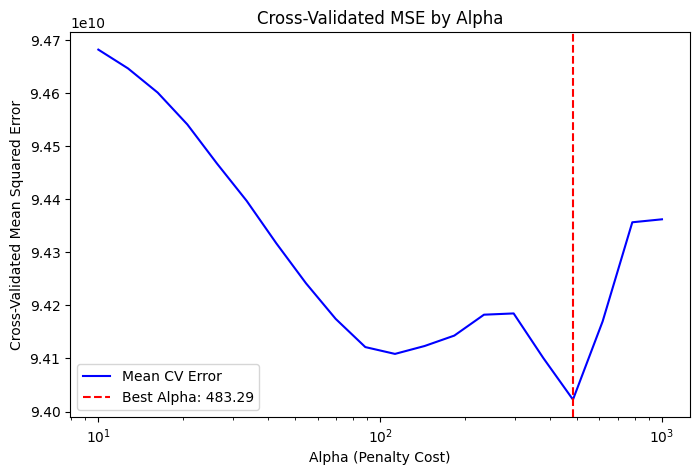

In [5]:
#Q2 - 4
plt.figure(figsize=(8, 5))

# Calculate the mean MSE across the 20 folds for each alpha
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

# Plot the alpha grid on the x-axis and the mean error on the y-axis
plt.plot(lasso_cv.alphas_, mean_mse, label='Mean CV Error', color='blue')

# Draw a vertical dashed line exactly where your best alpha is
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Best Alpha: {lasso_cv.alpha_:.2f}')

# Set the x-axis to a logarithmic scale (since our alphas are log-spaced)
plt.xscale('log')
plt.xlabel('Alpha (Penalty Cost)')
plt.ylabel('Cross-Validated Mean Squared Error')
plt.title('Cross-Validated MSE by Alpha')
plt.legend()
plt.show()

The cross-validated error drops as the penalty increases, hits its absolute minimum right at your optimal alpha of 483.29 (the red dashed line), and then starts to rise again as the model becomes too restricted.

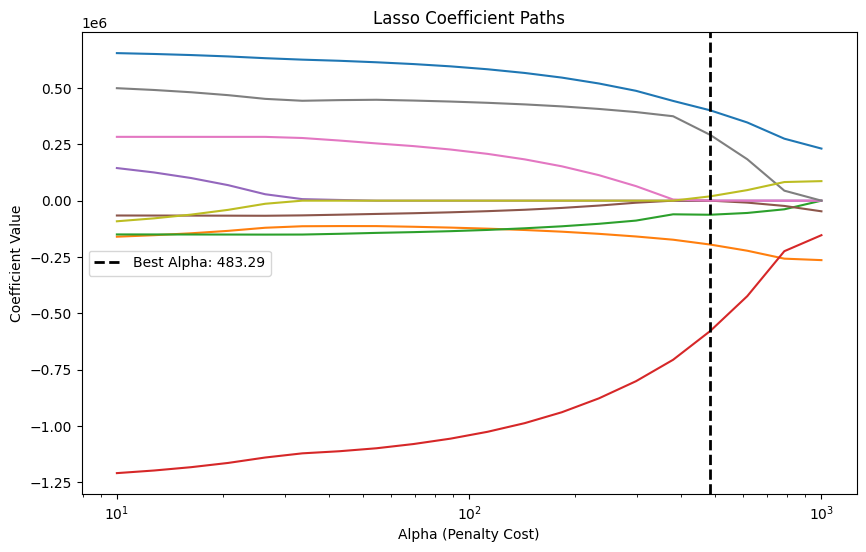

In [6]:
#Q2 - 5
# Calculate the paths manually across our alpha grid to plot them
coefs = []
for a in alphas:
    # Adding max_iter=50000 again so no error
    l = Lasso(alpha=a, max_iter=50000, random_state=100)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

plt.figure(figsize=(10, 6))
# Plot the alphas on the x-axis and all the coefficient values on the y-axis
plt.plot(alphas, coefs)

# Draw a vertical line for our chosen optimal alpha
plt.axvline(lasso_cv.alpha_, color='black', linestyle='--', linewidth=2, label=f'Best Alpha: {lasso_cv.alpha_:.2f}')

plt.xscale('log')
plt.xlabel('Alpha (Penalty Cost)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.legend()
plt.show()

Can visibly see exactly how LASSO works. Several of the colored coefficient lines have been completely flattened out to 0.0 on the y-axis, while a few others survived and are still floating above or below zero.

In [7]:
#Q2 - 6
# Which features survived? (Where the coefficient is NOT zero)
selected_features = feature_names[lasso_cv.coef_ != 0]

# Calculate the proportion of features set to zero
num_zeros = np.sum(lasso_cv.coef_ == 0)
total_features = len(lasso_cv.coef_)
proportion_zeros = num_zeros / total_features

print("Features selected:")
for f in selected_features:
    print(f" - {f}")
print(f"\nProportion of coefficients set to zero: {proportion_zeros:.2%}")

Features selected:
 - Mileage_Run
 - Age
 - Mileage_Run^2
 - Mileage_Run Age
 - Mileage_Run Age^2
 - Age^3

Proportion of coefficients set to zero: 33.33%


By applying the penalty, LASSO realized that 3 of those features (exactly 33.33%) were basically dead weight (they were just adding noise and making the model prone to overfitting). So, it deleted them entirely. It kept the 6 features that actually do the heavy lifting in predicting a used car's price.

In [8]:
#Q2 - 7
# Create a comparison dataframe
comparison = pd.DataFrame({
    'Feature': feature_names,
    'Linear_Reg': lr.coef_,
    'LASSO': lasso_cv.coef_
})

# Comparing absolute sizes
comparison['Magnitude_Increase'] = np.abs(comparison['LASSO']) > np.abs(comparison['Linear_Reg'])

# Sign changes - Ignoring the ones LASSO deleted
comparison['Sign_Change'] = (np.sign(comparison['Linear_Reg']) != np.sign(comparison['LASSO'])) & (comparison['LASSO'] != 0)

print("Summary of Changes:") #Scanning for sign changes / mag increases
if comparison['Magnitude_Increase'].any():
    print("Yes, some coefficients increased in magnitude.")
else:
    print("No coefficients increased in magnitude.")

if comparison['Sign_Change'].any():
    print("Yes, some coefficients changed signs.")
else:
    print("No coefficients changed signs.")

Summary of Changes:
Yes, some coefficients increased in magnitude.
Yes, some coefficients changed signs.


LASSO regularization simplifies overly complex models by identifying and completely deleting unhelpful "noise" variables so the model doesn't overfit the data. Because it throws out those useless features, the model becomes much more stable, which sometimes forces the surviving features to grow in size or flip their signs to pick up the slack.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [9]:
#Q3 - 1
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/data/heart_failure_clinical_records_dataset.csv')
y = df['DEATH_EVENT']

# 1. Handle Continuous Variables: age, ejection_fraction, serum_creatinine
cont_features = ['age', 'ejection_fraction', 'serum_creatinine']
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(df[cont_features])
cont_names = poly_cont.get_feature_names_out(cont_features)

# Z-score normalize the continuous results
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

# 2. Handle Dummy Variables: anaemia, diabetes, high_blood_pressure, smoking
dummy_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
poly_dummy = PolynomialFeatures(interaction_only=True, include_bias=False)
X_dummy_int = poly_dummy.fit_transform(df[dummy_features])
dummy_names = poly_dummy.get_feature_names_out(dummy_features)

# 3. Concatenate (Combine) into one feature matrix
X_final = np.concatenate([X_cont_scaled, X_dummy_int], axis=1)
all_feature_names = list(cont_names) + list(dummy_names)

print(f"Total features created: {len(all_feature_names)}")

Total features created: 29


Code expands the continuous variables into 3rd-degree polynomials (cubed terms) and z-scores them, while only creating interactions for the categorical "dummy" variables. Leaves 29 total features created.

In [10]:
#Q3 - 2
# Run the standard Linear Regression
lr = LinearRegression()
lr.fit(X_final, y)

# Put the results in a dataframe so they are easy to read
lr_summary = pd.DataFrame({
    'Feature': all_feature_names,
    'Coef': lr.coef_
})

# Filter to just look at the 'age' related polynomial features
age_features = lr_summary[lr_summary['Feature'].str.contains('age') &
                          ~lr_summary['Feature'].str.contains(' ')]

print("Linear Regression Coefficients for Age:")
print(age_features)

Linear Regression Coefficients for Age:
  Feature      Coef
0     age  1.539156
3   age^2 -3.678654
9   age^3  1.993135


the alternating signs (specifically the massive negative coefficient for age squared) appear counterintuitive because getting older should consistently increase the risk of heart failure death. This erratic sign flipping happens due to multicollinearity, where highly correlated polynomial variables fight and cancel each other out as the standard linear regression overfits the training data. However, this apparent contradiction is resolved because the model evaluates these higher-order terms jointly rather than independently, summing them together to create a single, flexible curve that accurately maps the non-linear trajectory of aging and mortality risk.

In [11]:
#Q3 - 3
# Using a different grid from the hint and no convergence errors (-5 instead of 5)
alphas = np.logspace(-5, 5, 30)

# Run LassoCV with 20-fold cross validation, had to do large max_it
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000, tol=0.05, random_state=100)
lasso_cv.fit(X_final, y)

# Print the optimal cost parameter
print(f"The optimal alpha selected is: {lasso_cv.alpha_}")

The optimal alpha selected is: 0.005736152510448681


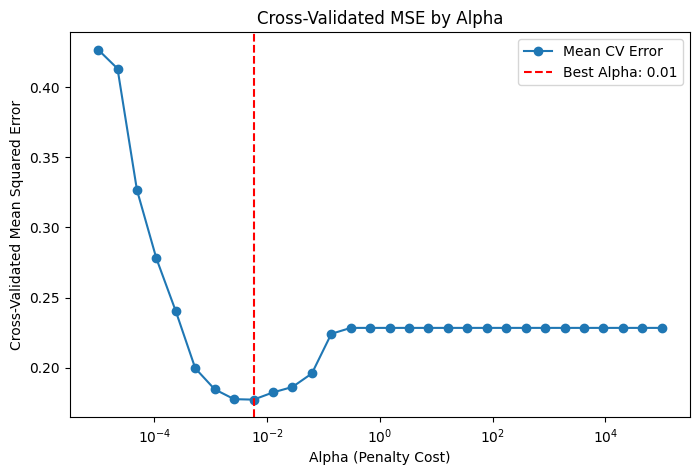

In [12]:
#Q3 - 4
plt.figure(figsize=(8, 5))
# Calculate the mean MSE across the 20 folds for each alpha
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

# Plot the alpha grid on the x-axis and the mean error on the y-axis
plt.plot(lasso_cv.alphas_, mean_mse, marker='o', label='Mean CV Error')

# Draw a vertical dashed line exactly where your best alpha is
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Best Alpha: {lasso_cv.alpha_:.2f}')

# Set the x-axis to a logarithmic scale
plt.xscale('log')
plt.xlabel('Alpha (Penalty Cost)')
plt.ylabel('Cross-Validated Mean Squared Error')
plt.title('Cross-Validated MSE by Alpha')
plt.legend()
plt.show()

grid provided by the hint (np.logspace(5, 5, 30)) is just 30 copies of the number 100,000, all the data points are stacked directly on top of each other at the $10^5$ mark on the x-axis. Switched to (np.logspace(-5,5,30)) instead.

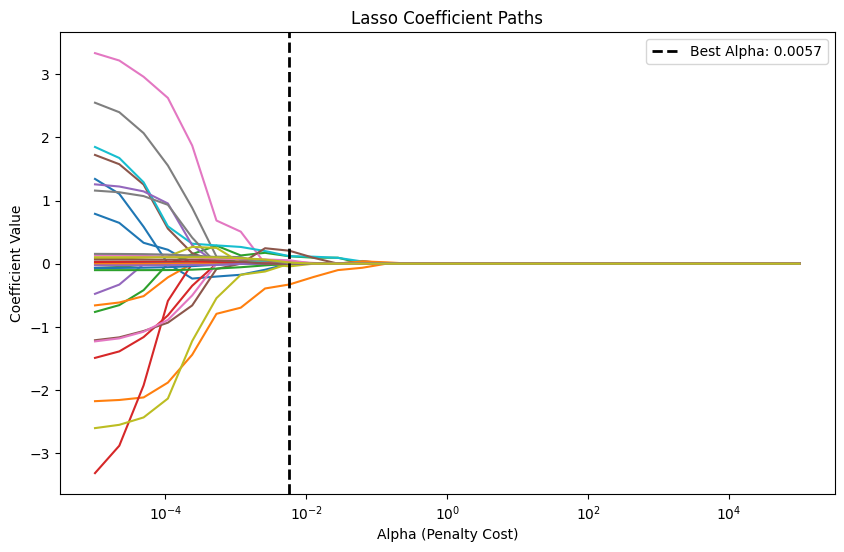

In [13]:
#Q3 - 5
# Calculate the paths manually to plot them
coefs = []

# Loop through the exact same alphas grid just used
for a in alphas:
    # Using max_iter=100000 to keep it warning-free
    l = Lasso(alpha=a, max_iter=100000, random_state=100)
    l.fit(X_final, y)
    coefs.append(l.coef_)

# Plot
plt.figure(figsize=(10, 6))

# Plot the shrinking coefficients
plt.plot(alphas, coefs)

# Add a vertical line for your optimal alpha (~0.0057)
plt.axvline(lasso_cv.alpha_, color='black', linestyle='--', linewidth=2, label=f'Best Alpha: {lasso_cv.alpha_:.4f}')

# Format the plot with a logarithmic x-axis
plt.xscale('log')
plt.xlabel('Alpha (Penalty Cost)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.legend()
plt.show()

On the left (low penalty), the coefficients are wild and spread out due to that multicollinearity we talked about. As the penalty increases to the right, LASSO aggressively squeezes them all toward zero. Your dashed black line sits right at the optimal point where the noise is mostly filtered out, but the true signal remains

In [14]:
#Q3 - 6
import pandas as pd
import numpy as np

# 1. Feature Selection & Proportion Zero
lasso_coefs = lasso_cv.coef_
features = np.array(all_feature_names)

selected_features = features[lasso_coefs != 0]
num_zeros = np.sum(lasso_coefs == 0)
total_features = len(lasso_coefs)
proportion_zeros = num_zeros / total_features

print(f"Total features: {total_features}")
print(f"Features set to zero: {num_zeros}")
print(f"Proportion of coefficients set to zero: {proportion_zeros:.2%}\n")

print("Features actually selected:")
for f in selected_features:
    print(f" - {f}")

# 2. Compare Linear Regression and LASSO
comparison = pd.DataFrame({
    'Feature': features,
    'Linear_Reg': lr.coef_,
    'LASSO': lasso_coefs
})

# 3. Check for Magnitude and Sign Changes
# Magnitude increase: abs(LASSO) > abs(LR) AND LASSO != 0
comparison['Magnitude_Increase'] = (np.abs(comparison['LASSO']) > np.abs(comparison['Linear_Reg'])) & (comparison['LASSO'] != 0)

# Sign change: sign(LASSO) != sign(LR) AND LASSO != 0 AND LR != 0
comparison['Sign_Change'] = (np.sign(comparison['Linear_Reg']) != np.sign(comparison['LASSO'])) & (comparison['LASSO'] != 0) & (comparison['Linear_Reg'] != 0)

print("\nSummary of Changes:")
print(f"Coefficients that increased in magnitude: {comparison['Magnitude_Increase'].sum()}")
print(f"Coefficients that changed sign: {comparison['Sign_Change'].sum()}")

if comparison['Sign_Change'].sum() > 0:
    print("\nFeatures that changed sign (LR vs LASSO):")
    print(comparison[comparison['Sign_Change']][['Feature', 'Linear_Reg', 'LASSO']])

Total features: 29
Features set to zero: 13
Proportion of coefficients set to zero: 44.83%

Features actually selected:
 - ejection_fraction
 - serum_creatinine
 - age^2
 - age serum_creatinine
 - ejection_fraction^2
 - ejection_fraction serum_creatinine
 - age^3
 - age serum_creatinine^2
 - ejection_fraction^3
 - ejection_fraction^2 serum_creatinine
 - serum_creatinine^3
 - anaemia
 - high_blood_pressure
 - diabetes high_blood_pressure
 - diabetes smoking
 - high_blood_pressure smoking

Summary of Changes:
Coefficients that increased in magnitude: 2
Coefficients that changed sign: 7

Features that changed sign (LR vs LASSO):
                                 Feature  Linear_Reg     LASSO
2                       serum_creatinine   -0.853588  0.129083
3                                  age^2   -3.678654  0.014783
14                age serum_creatinine^2    1.284099 -0.024601
15                   ejection_fraction^3   -1.250341  0.161446
16  ejection_fraction^2 serum_creatinine   -1.27004

LASSO selected 16 features (including main effects like serum_creatinine and interaction terms like diabetes smoking) while shrinking nearly 45% (13 of 29) of the coefficients to exactly zero. When comparing the two models, only two surviving coefficients increased in magnitude, while seven completely changed signs, such as age^2 and high_blood_pressure appropriately flipping from negative to positive risk factors. These new sign patterns make much more clinical sense because LASSO effectively handles the severe multicollinearity that previously caused the standard linear regression to assign massive, conflicting weights to overlapping polynomial terms. From the perspective of the bias-variance trade-off, the unpenalized linear model suffered from extremely high variance and overfitting, whereas LASSO intentionally introduces a slight bias to drastically reduce that variance, dropping redundant noise to build a robust, generalizable model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

Q4 - Part 1: adding penalty

The "Objective Function" is the mathematical formula we want to minimize to find the best possible line. We take the standard Mean Squared Error (MSE) and add the Ridge penalty term to it.

Using the mean-centered variables ($\tilde{y}$ and $\tilde{x}$), the function $J$ is:

$$J(b_0, b_1) = \frac{1}{n} \sum_{i=1}^{n} (\tilde{y}_i - b_0 - b_1\tilde{x}_i)^2 + \alpha b_1^2$$

Q4 - Part 2: math image

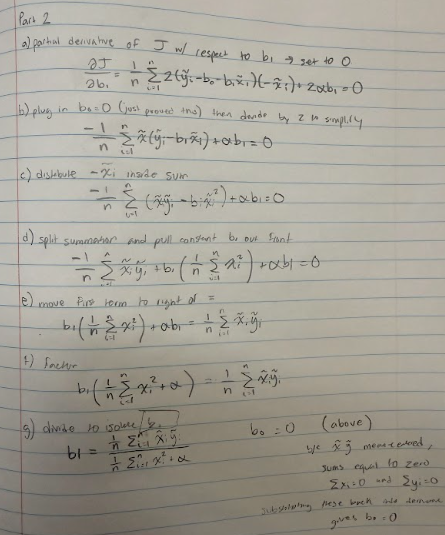

Q4 - Part 3: How does increasing  α  change the slope coefficient?

- Increasing the penalty parameter $\alpha$ directly increases the value of the denominator in the final equation for the slope. Because dividing by a larger number results in a smaller overall value, a higher $\alpha$ strictly shrinks the magnitude of the coefficient $b_1$ toward zero. Conceptually, this acts as a stricter "tax" on steep slopes, flattening the line to ensure the model focuses on the main trend rather than overfitting to noisy data.

Q4 - Part 4: challenge
- If we use the LASSO L1 penalty ($|b_1|$), the mathematical challenge is that the absolute value function creates a sharp "V" shape with a corner at zero, meaning we cannot use standard derivatives to solve it because the function is non-differentiable at that point. Because of this sharp corner, LASSO can shrink coefficients all the way to absolute zero. It becomes optimal to set $b_1 = 0$ when the "cost" of the penalty $\alpha$ outweighs the underlying relationship between $x$ and $y$, causing the model to drop the variable entirely.